In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv("insurance (1).csv")

df = pd.get_dummies(df, drop_first=True)

X = df.drop("charges", axis=1)
y = df["charges"]


In [4]:
print(df.columns)

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [6]:
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.8651034329144947


In [8]:
import pandas as pd

age = int(input("Age: "))
bmi = float(input("BMI: "))
children = int(input("Children: "))

sex = 1 if input("Male? (yes/no): ").lower() == "yes" else 0
smoker = 1 if input("Smoker? (yes/no): ").lower() == "yes" else 0

region = input("Region (northwest/southeast/southwest/other): ").lower()

nw = 1 if region == "northwest" else 0
se = 1 if region == "southeast" else 0
sw = 1 if region == "southwest" else 0

new_data = pd.DataFrame({
    "age":[age],
    "bmi":[bmi],
    "children":[children],
    "sex_male":[sex],
    "smoker_yes":[smoker],
    "region_northwest":[nw],
    "region_southeast":[se],
    "region_southwest":[sw]
})

price = model.predict(new_data)

print("Insurance Cost =", round(price[0], 2))

Age: 30
BMI: 25.5
Children: 2
Male? (yes/no): no
Smoker? (yes/no): no
Region (northwest/southeast/southwest/other): southwest
Insurance Cost = 5344.93


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [11]:
df = pd.read_csv("heart.csv")

X = df.drop("target", axis=1)
y = df["target"]

In [12]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.9853658536585366
[[102   0]
 [  3 100]]


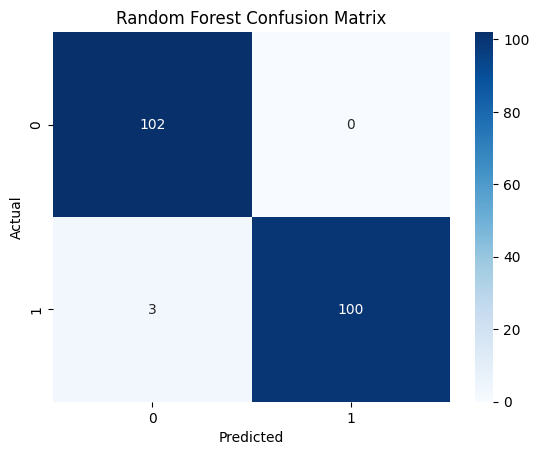

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [16]:
import pandas as pd

age = int(input("Age: "))
sex = int(input("Sex (1=Male, 0=Female): "))
cp = int(input("Chest Pain Type (0-3): "))
trestbps = int(input("Resting Blood Pressure: "))
chol = int(input("Cholesterol: "))
fbs = int(input("Fasting Blood Sugar >120 (1=Yes, 0=No): "))
restecg = int(input("Rest ECG (0-2): "))
thalach = int(input("Maximum Heart Rate: "))
exang = int(input("Exercise Induced Angina (1=Yes, 0=No): "))
oldpeak = float(input("Old Peak: "))
slope = int(input("Slope (0-2): "))
ca = int(input("Number of Major Vessels (0-4): "))
thal = int(input("Thal (0-3): "))

new_data = pd.DataFrame({
    'age':[age],
    'sex':[sex],
    'cp':[cp],
    'trestbps':[trestbps],
    'chol':[chol],
    'fbs':[fbs],
    'restecg':[restecg],
    'thalach':[thalach],
    'exang':[exang],
    'oldpeak':[oldpeak],
    'slope':[slope],
    'ca':[ca],
    'thal':[thal]
})

prediction = model.predict(new_data)

if prediction[0] == 1:
    print("\nHeart Disease Detected")
else:
    print("\nNo Heart Disease")

Age: 52
Sex (1=Male, 0=Female): 1
Chest Pain Type (0-3): 2
Resting Blood Pressure: 130
Cholesterol: 230
Fasting Blood Sugar >120 (1=Yes, 0=No): 1
Rest ECG (0-2): 1
Maximum Heart Rate: 150
Exercise Induced Angina (1=Yes, 0=No): 0
Old Peak: 1.5
Slope (0-2): 1
Number of Major Vessels (0-4): 3
Thal (0-3): 2

Heart Disease Detected


In [20]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [21]:
df = pd.read_csv("candidate_selection_dataset.csv")
df

,Skill,Communication,Project_Level,Result
0,Python,Good,High,Selected
1,Java,Average,Medium,Selected
2,C,Poor,Low,Rejected
3,Python,Excellent,High,Selected
4,Java,Poor,Low,Rejected
5,C++,Good,Medium,Selected
6,Python,Average,Medium,Selected
7,Java,Good,Low,Rejected
8,C,Excellent,High,Selected
9,C++,Poor,Low,Rejected


In [22]:
le_skill = LabelEncoder()
le_comm = LabelEncoder()
le_project = LabelEncoder()
le_result = LabelEncoder()

df["Skill"] = le_skill.fit_transform(df["Skill"])
df["Communication"] = le_comm.fit_transform(df["Communication"])
df["Project_Level"] = le_project.fit_transform(df["Project_Level"])
df["Result"] = le_result.fit_transform(df["Result"])

# Input and Output
X = df[["Skill", "Communication", "Project_Level"]]
y = df["Result"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Decision Tree Model
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

In [24]:
y_pred = model.predict(X_test)

# Validation
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score:
1.0

Confusion Matrix:
[[1 0]
 [0 3]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [25]:
print("\nEnter Candidate Details")

skill = input("Skill (Python/Java/C/C++): ")
communication = input("Communication (Poor/Average/Good/Excellent): ")
project = input("Project Level (Low/Medium/High): ")

# Convert Text to Numeric
skill = le_skill.transform([skill])[0]
communication = le_comm.transform([communication])[0]
project = le_project.transform([project])[0]

# Create DataFrame
new_data = pd.DataFrame({
    "Skill": [skill],
    "Communication": [communication],
    "Project_Level": [project]
})

# Predict
prediction = model.predict(new_data)

# Convert Back to Original Label
result = le_result.inverse_transform(prediction)

print("\nPrediction:", result[0])


Enter Candidate Details
Skill (Python/Java/C/C++): Python
Communication (Poor/Average/Good/Excellent): Average
Project Level (Low/Medium/High): Medium

Prediction: Selected
